# OCR manuscrit spécialisés contre modèles internes

In [5]:
import base64
import io
import json
import os
import random
import re
import shutil
import subprocess
import time
import unicodedata
from pathlib import Path

os.environ["HF_HOME"] = os.path.expanduser("~/work/.cache/huggingface")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
import torch
from PIL import Image

BUCKET = "projet-mesure-qualite-rp"
CAMPAGNE = "RG25"
CHAMPS = ["NOM", "PRENOM"]

DOSSIER_LIGNES = Path("lignes_bi")
MANIFESTE = DOSSIER_LIGNES / "manifeste.csv"

# --- A renseigner une fois ------------------------------------------
POS_UT, POS_CAB = 2, 4
COLS = {"NOM": 11, "PRENOM": 12}       # numeros de colonnes du Fiqual type 3

ZONES_SECOURS = {"NOM": (0.155, 0.083, 0.245, 0.011),
                 "PRENOM": (0.155, 0.094, 0.245, 0.011)}

APPAREIL = "cuda" if torch.cuda.is_available() else "cpu"
print("appareil :", APPAREIL,
      f"({torch.cuda.get_device_name(0)})" if APPAREIL == "cuda" else "")
u = shutil.disk_usage(os.path.expanduser("~/work"))
print(f"disque   : {u.free/1e9:.1f} Go libres — prevoir 2 Go")

appareil : cuda (Tesla T4)
disque   : 3.4 Go libres — prevoir 2 Go


In [6]:
def normaliser(t):
    """Majuscules, sans accent, espaces ecrases : le format du Fiqual."""
    if t is None or (isinstance(t, float) and pd.isna(t)):
        return ""
    t = unicodedata.normalize("NFKD", str(t).strip())
    t = "".join(c for c in t if not unicodedata.combining(c)).upper()
    t = re.sub(r"[^A-Z0-9 ]", " ", t)
    return re.sub(r"\s+", " ", t).strip()


def distance(a, b):
    """Nombre de caracteres a changer pour passer de a a b."""
    if a == b:
        return 0
    if not a:
        return len(b)
    if not b:
        return len(a)
    prec = list(range(len(b) + 1))
    for i, ca in enumerate(a, 1):
        cour = [i]
        for j, cb in enumerate(b, 1):
            cour.append(min(prec[j] + 1, cour[j - 1] + 1, prec[j - 1] + (ca != cb)))
        prec = cour
    return prec[-1]


MARQUEURS_ILLISIBLE = ("ILLISIBLE", "UNREADABLE", "NON LISIBLE", "INCONNU")


def classer(lu, ref):
    """exact, illisible avoue, ou invente."""
    l, r = normaliser(lu), normaliser(ref)
    if l == "" or any(m in l for m in MARQUEURS_ILLISIBLE):
        return "illisible"
    return "exact" if l == r else "invente"


def mesures(d):
    """Les metriques, identiques pour tous les moteurs."""
    d = d.copy()
    d["etat"] = [classer(a, b) for a, b in zip(d.lu, d.attendu)]
    d["dist"] = [distance(normaliser(a), normaliser(b))
                 for a, b in zip(d.lu, d.attendu)]
    d["len"] = d.attendu.map(lambda x: len(normaliser(x)))

    m = {"N": len(d)}
    for champ in sorted(d.champ.unique()):
        s = d[d.champ == champ]
        m[f"{champ}_exact"] = float((s.etat == "exact").mean())
        m[f"{champ}_illisible"] = float((s.etat == "illisible").mean())
        m[f"{champ}_invente"] = float((s.etat == "invente").mean())
        lis = s[s.etat != "illisible"]
        if lis["len"].sum():
            m[f"{champ}_cer"] = float(lis.dist.sum() / lis["len"].sum())
    m["global_exact"] = float((d.etat == "exact").mean())
    m["global_invente"] = float((d.etat == "invente").mean())
    return m


# Verification rapide
for a, b in [("Élodie", "ELODIE"), ("MARTAN", "MARTIN"), ("ILLISIBLE", "MARTIN")]:
    print(f"  {a!r:12} vs {b!r:10} -> {classer(a, b)}")

  'Élodie'     vs 'ELODIE'   -> exact
  'MARTAN'     vs 'MARTIN'   -> invente
  'ILLISIBLE'  vs 'MARTIN'   -> illisible


# Découper les lignes



In [7]:


def preparer_lignes():
    if MANIFESTE.exists():
        man = pd.read_csv(MANIFESTE, dtype=str).fillna("")
        lignes = [{"id": r["id"], "cle": r["cle"], "champ": r["champ"],
                   "texte": r["texte"],
                   "image": Image.open(DOSSIER_LIGNES / f"{r['id']}.png").convert("RGB")}
                  for _, r in man.iterrows()]
        print(f"{len(lignes)} lignes rechargees depuis {MANIFESTE}")
        return lignes

    import s3fs
    fs = s3fs.S3FileSystem()

    def charger(chemin):
        with fs.open(chemin, "rb") as f:
            return Image.open(io.BytesIO(f.read())).convert("RGB")

    def decouper_frac(image, zone):
        L, H = image.size
        x, y, w, h = zone
        return image.crop((int(x * L), int(y * H), int((x + w) * L), int((y + h) * H)))

    cz = Path(f"configs/positions_BI_{CAMPAGNE}.json")
    zones = ({k: tuple(v) for k, v in
              json.loads(cz.read_text(encoding="utf-8"))["zones"].items()}
             if cz.exists() else dict(ZONES_SECOURS))
    print("zones :", {k: zones.get(k) for k in CHAMPS})

    fichiers = [f for f in fs.find(f"{BUCKET}/data/raw/{CAMPAGNE}/BIE")
                if f.endswith("_BI.jpg")]
    bi = pd.DataFrame({"chemin": fichiers})
    m = bi.chemin.map(lambda c: Path(c).stem).str.split("_")
    bi["cle"] = m.str[0] + "_" + m.str[1]

    ligne_brute = pd.read_csv(
        f"s3://{BUCKET}/data/raw/{CAMPAGNE}/RP_PMQ_FIQUAL2599.txt",
        sep="\x00", header=None, names=["ligne"], dtype=str, encoding="latin-1",
        keep_default_na=False, engine="python")["ligne"]
    ch = ligne_brute.str.split("|")
    fq3 = pd.DataFrame(ch[ch.str[0] == "3"].tolist(), dtype=str)
    fq3["cle"] = fq3[POS_UT].str.strip() + "_" + fq3[POS_CAB].str.strip()

    cols = {k: v for k, v in COLS.items() if v is not None}
    if not cols:
        print("\nRenseigner COLS. Colonnes alphabetiques candidates :\n")
        for c in fq3.columns:
            if c == "cle":
                continue
            v = fq3[c].str.strip()
            v = v[v != ""]
            if v.empty:
                continue
            if v.str.fullmatch(r"[A-Za-z' \-]+").mean() > 0.9 and v.nunique() > 20:
                print(f"  colonne {c:3} — {v.nunique():4} valeurs, "
                      f"exemples : {list(v.head(3))}")
        print("\nLe nom a plus de valeurs distinctes que le prenom.")
        return []

    ref = fq3[["cle"] + list(cols.values())].copy()
    ref.columns = ["cle"] + [f"ref_{k}" for k in cols]
    for c in ref.columns[1:]:
        ref[c] = ref[c].str.strip()
    app = bi.merge(ref, on="cle", how="inner").reset_index(drop=True)

    DOSSIER_LIGNES.mkdir(exist_ok=True)
    lignes, rangs = [], []
    for _, r in app.iterrows():
        page = charger(r.chemin)
        for champ in CHAMPS:
            texte = str(r.get(f"ref_{champ}", "")).strip()
            if not texte or champ not in zones:
                continue
            ident = f"ligne_{len(lignes):04d}"
            v = decouper_frac(page, zones[champ])
            v.save(DOSSIER_LIGNES / f"{ident}.png")
            lignes.append({"id": ident, "cle": r.cle, "champ": champ,
                           "texte": texte, "image": v})
            rangs.append({"id": ident, "cle": r.cle, "champ": champ, "texte": texte})

    pd.DataFrame(rangs).to_csv(MANIFESTE, index=False)
    print(f"\n{len(lignes)} lignes exportees dans {DOSSIER_LIGNES}/")
    return lignes


def enregistrer_predictions(lignes, lus, moteur):
    d = pd.DataFrame({"id": [l["id"] for l in lignes],
                      "cle": [l["cle"] for l in lignes],
                      "champ": [l["champ"] for l in lignes],
                      "attendu": [l["texte"] for l in lignes],
                      "lu": lus})
    d.to_csv(f"predictions_{moteur}.csv", index=False)
    print(f"{len(d)} predictions ecrites dans predictions_{moteur}.csv")
    return d


def tracer_mlflow(d, moteur, famille, modele, secondes_par_ligne=float("nan")):
    """Enregistre un essai dans l'experience commune du projet."""
    try:
        import mlflow
        mlflow.set_experiment("fiqual-banc-essai")
        m = mesures(d)
        nom = f"ligne-{moteur}-N{m['N']}"
        with mlflow.start_run(run_name=nom):
            mlflow.log_params({
                "moteur": moteur, "famille": famille, "modele": modele,
                "entree": "ligne isolee, pleine resolution",
                "campagne": CAMPAGNE, "champs": ",".join(CHAMPS),
                "N_lignes": m["N"], "appareil": APPAREIL,
                "secondes_par_ligne": round(secondes_par_ligne, 3),
            })
            mlflow.log_metrics(m)
            mlflow.log_artifact(f"predictions_{moteur}.csv")
            if MANIFESTE.exists():
                mlflow.log_artifact(str(MANIFESTE))
        print(f"essai « {nom} » enregistre dans MLflow")
        return m
    except Exception as e:
        print("MLflow indisponible :", type(e).__name__, e)
        return mesures(d)


LIGNES = preparer_lignes()
if LIGNES:
    print(pd.Series([l["champ"] for l in LIGNES]).value_counts().to_string())
    t = [l["image"].size for l in LIGNES]
    print(f"taille mediane : {int(np.median([x[0] for x in t]))} x "
          f"{int(np.median([x[1] for x in t]))} px")
     


     


zones : {'NOM': (0.155, 0.083, 0.245, 0.011), 'PRENOM': (0.155, 0.094, 0.245, 0.011)}

335 lignes exportees dans lignes_bi/
NOM       168
PRENOM    167
taille mediane : 406 x 52 px


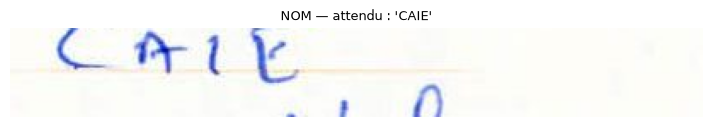

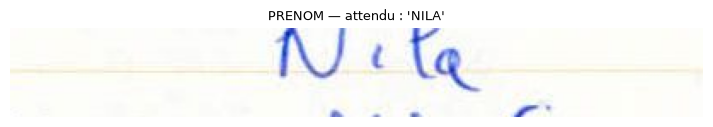

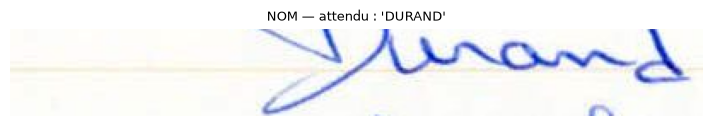

In [8]:
# Controle visuel : indispensable avant tout le reste
for l in LIGNES[:3]:
    v = l["image"]
    fig, ax = plt.subplots(figsize=(9, 9 * v.size[1] / max(v.size[0], 1)))
    ax.imshow(v)
    ax.set_title(f"{l['champ']} — attendu : {l['texte']!r}", fontsize=9)
    plt.axis("off")
    plt.show()

# Partie I  TrOCR

# I.1 Charger le modèle

In [11]:
from huggingface_hub import snapshot_download

MODELE_TROCR = "microsoft/trocr-base-handwritten"

try:
    DOSSIER_TROCR = snapshot_download(MODELE_TROCR)
    print("fichiers du modele :\n")
    for f in sorted(Path(DOSSIER_TROCR).iterdir()):
        if f.is_file():
            print(f"  {f.name:30} {f.stat().st_size/1e6:7.2f} Mo")
except Exception as e:
    DOSSIER_TROCR = None
    print("ECHEC du telechargement :", type(e).__name__, e)

/opt/python/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Fetching 11 files: 100%|██████████| 11/11 [00:22<00:00,  2.02s/it]

fichiers du modele :

  .gitattributes                    0.00 Mo
  README.md                         0.00 Mo
  config.json                       0.00 Mo
  generation_config.json            0.00 Mo
  merges.txt                        0.46 Mo
  model.safetensors              1333.38 Mo
  preprocessor_config.json          0.00 Mo
  pytorch_model.bin              1333.51 Mo
  special_tokens_map.json           0.00 Mo
  tokenizer_config.json             0.00 Mo
  vocab.json                        0.90 Mo


In [19]:
img_proc = tokenizer = model_trocr = None
strategie = None
erreurs = []


def _tenter(nom, f):
    global img_proc, tokenizer, strategie
    if strategie:
        return
    try:
        ip, tk = f()
        assert ip is not None and tk is not None
        img_proc, tokenizer, strategie = ip, tk, nom
        print(f"  {nom:32} OK")
    except Exception as e:
        erreurs.append((nom, f"{type(e).__name__}: {e}"))
        print(f"  {nom:32} {type(e).__name__}")


def _t1():
    from transformers import TrOCRProcessor
    p = TrOCRProcessor.from_pretrained(MODELE_TROCR)
    return p.image_processor, p.tokenizer


def _t2():
    from transformers import TrOCRProcessor
    p = TrOCRProcessor.from_pretrained(MODELE_TROCR, use_fast=False)
    return p.image_processor, p.tokenizer


def _t3():
    from transformers import AutoImageProcessor, AutoTokenizer
    return (AutoImageProcessor.from_pretrained(MODELE_TROCR),
            AutoTokenizer.from_pretrained(MODELE_TROCR, use_fast=False))


def _t4():
    from transformers import ViTImageProcessor, RobertaTokenizer
    return (ViTImageProcessor.from_pretrained(MODELE_TROCR),
            RobertaTokenizer.from_pretrained(MODELE_TROCR))


def _t5():
    from transformers import ViTImageProcessor, RobertaTokenizer
    d = Path(DOSSIER_TROCR)
    return (ViTImageProcessor.from_pretrained(str(d)),
            RobertaTokenizer(vocab_file=str(d / "vocab.json"),
                             merges_file=str(d / "merges.txt")))


print("recherche d'une methode de chargement :")
for nom, f in [("1 processor standard", _t1), ("2 tokenizer lent", _t2),
               ("3 composants separes", _t3), ("4 classes explicites", _t4),
               ("5 fichiers locaux directs", _t5)]:
    _tenter(nom, f)

if strategie:
    from transformers import VisionEncoderDecoderModel
    model_trocr = VisionEncoderDecoderModel.from_pretrained(
        MODELE_TROCR).to(APPAREIL).eval()
    print(f"\ncharge via « {strategie} » — "
          f"{sum(p.numel() for p in model_trocr.parameters())/1e6:.0f} M parametres")
else:
    print("\nAucune methode. Detail des erreurs :\n")
    for nom, e in erreurs:
        print(f"  {nom}\n    {e[:200]}\n")
    print("Si le cache est incomplet, passer REPARER a True ci-dessous.")
     

recherche d'une methode de chargement :
  1 processor standard             ValueError


[transformers] The `use_fast` parameter is deprecated and will be removed in a future version. Use `backend="torchvision"` instead of `use_fast=True`, or `backend="pil"` instead of `use_fast=False`.
[transformers] `ViTImageProcessor` requires torchvision (not installed); falling back to `ViTImageProcessorPil` for backward compatibility. Install torchvision to use the default backend, or import `ViTImageProcessorPil` directly to silence this warning.


  2 tokenizer lent                 ValueError
  3 composants separes             ImportError
  4 classes explicites             OK


Loading weights: 100%|██████████| 478/478 [00:00<00:00, 3848.79it/s]
[transformers] VisionEncoderDecoderModel LOAD REPORT from: microsoft/trocr-base-handwritten
Key                         | Status  | 
----------------------------+---------+-
encoder.pooler.dense.weight | MISSING | 
encoder.pooler.dense.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



charge via « 4 classes explicites » — 334 M parametres


In [20]:
REPARER = False

if REPARER:
    shutil.rmtree(os.path.expanduser(
        "~/work/.cache/huggingface/hub/models--microsoft--trocr-base-handwritten"),
        ignore_errors=True)
    print("cache efface — relancer les deux cellules precedentes")